In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from xgboost import XGBClassifier

In [2]:
#!wget 'https://data.mendeley.com/datasets/m8cgwxs9s6/2/files/4c109a9f-2462-4dce-b93c-5789168c5401'

In [3]:
#!unzip raw_data/example.zip

In [4]:
path = "/home/candelaneumann/code/CandeNeu/pulseIQ/pulseiq/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv"
df = pd.read_csv(path)
df.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


In [5]:
df1 = df.copy()

In [6]:
'''
Droping the ID columns
'''

df1 = df.drop(columns=['systolic_bp', 'diastolic_bp', 'family_diabetes', 'family_hypertension', 'glucose', 'stroke'])

In [7]:
df1.head(2)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,Female,66,1.65,70.2,25.75,0,0,No
1,35,Female,60,1.47,42.5,19.58,0,0,No


In [8]:
'''
Binaryzing Diabetes to 0 = Normal and 1 = Diabetes
'''

map_diabetes = {
    'No': 0,
    'Yes': 1
}

df1['diabetic'] = df1['diabetic'].map(map_diabetes)

In [9]:
'''
Binaryzing Sex to 0 = Female and 1 = Male
'''

map_sex = {
    'Female': 0,
    'Male': 1
}

df1['gender'] = df1['gender'].map(map_sex)

In [10]:
df1.head(4)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,0,66,1.65,70.2,25.75,0,0,0
1,35,0,60,1.47,42.5,19.58,0,0,0
2,62,0,57,1.52,47.0,20.24,0,0,0
3,73,1,55,1.63,57.4,21.72,0,0,0


In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   int64  
 2   pulse_rate              5288 non-null   int64  
 3   height                  5288 non-null   float64
 4   weight                  5288 non-null   float64
 5   bmi                     5288 non-null   float64
 6   hypertensive            5288 non-null   int64  
 7   cardiovascular_disease  5288 non-null   int64  
 8   diabetic                5288 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 371.9 KB


In [12]:
df1.head(2)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,0,66,1.65,70.2,25.75,0,0,0
1,35,0,60,1.47,42.5,19.58,0,0,0


In [13]:

'''
Scanling the dataset
'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()




X_scaled = scaler.set_output(transform='pandas').fit_transform(df1[['age', 'pulse_rate', 'height', 'weight', 'bmi']])
y_diabetic = df1['diabetic']
y_hypertensive = df1['hypertensive']
y_cv = df1['cardiovascular_disease']


In [14]:
y_diabetic

0       0
1       0
2       0
3       0
4       0
       ..
5283    0
5284    1
5285    0
5286    0
5287    0
Name: diabetic, Length: 5288, dtype: int64

<Axes: >

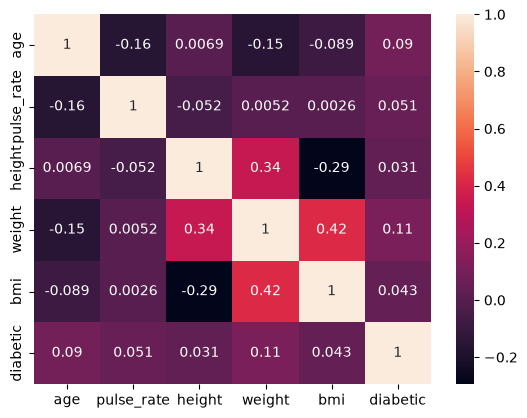

In [15]:
sns.heatmap(pd.concat([X_scaled, y_diabetic], axis=1).corr(), annot=True)

## Logistic Regression baseline

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier

model = LogisticRegression(random_state=42)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_scaled, y_diabetic, train_size=0.7, random_state=42, stratify=y_diabetic)

model.fit(X_train_d, y_train_d)

cv = cross_validate(model, X_train_d, y_train_d, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.683312668902541)

In [17]:
model = LogisticRegression(random_state=42)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_scaled, y_hypertensive, train_size=0.7, random_state=42, stratify=y_hypertensive)

model.fit(X_train_h, y_train_h)

cv = cross_validate(model, X_train_h, y_train_h, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.7366587857844008)

In [18]:
model = LogisticRegression(random_state=42)

X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X_scaled, y_cv, train_size=0.7, random_state=42, stratify=y_cv)

model.fit(X_train_cv, y_train_cv)

cv = cross_validate(model, X_train_cv, y_train_cv, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.7298592578472488)

In [19]:
from sklearn.metrics import roc_auc_score
def model_f(y):
    model_xgb = XGBClassifier(eval_metric='logloss')

    model_xgb.fit(X_scaled, y)

    cv_xgb = cross_validate(model_xgb, X_scaled, y, cv=5, scoring=['roc_auc'])

    skf = StratifiedKFold(n_splits=5)
    skf.get_n_splits()

    scores = []

    for i, (train_index, test_index) in enumerate(skf.split(X_scaled, y)):
        X_train = X_scaled.iloc[train_index]
        y_train = y.iloc[train_index]
        X_test = X_scaled.iloc[test_index]
        y_test = y.iloc[test_index]

        model_xgb = XGBClassifier(eval_metric='logloss')

        model_xgb.fit(X_train, y_train)

        y_pred = model_xgb.predict_proba(X_test)[:, 1]


        scores.append(roc_auc_score(y_test, y_pred))
    return np.mean(scores)

In [20]:
scores_d = model_f(y_diabetic)
scores_h = model_f(y_hypertensive)
scores_cv = model_f(y_cv)

In [21]:
scores_d, scores_h, scores_cv

(np.float64(0.6603345635857357),
 np.float64(0.7026213661682676),
 np.float64(0.6345794032709098))

In [41]:
import optuna
from sklearn.ensemble import RandomForestClassifier
def objective(trial):
    regression_model = trial.regressor_name = trial.suggest_categorical('classifier', ['XGBClassifier', 'LogisticRegression'])

    if regression_model == 'XGBClassifier':
        # Invoke suggest methods of a Trial object to generate hyperparameters.
        params = { 'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    #            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
    #            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    #            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
    #            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
    #            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1
                }
        regression_model = XGBClassifier(**params)

    elif regression_model == 'LogisticRegression':
        solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
        if solver == 'lbfgs':
            penalty = trial.suggest_categorical('penalty_lbfgs', ['l2', None])
        elif solver == 'liblinear': penalty = trial.suggest_categorical('penalty_liblinear',
                                                                        ['l1', 'l2'])
        elif solver == 'saga': penalty = trial.suggest_categorical('penalty_saga',
                                                                   ['l1', 'l2', 'elasticnet', None])
        # Parâmetros base comuns
        params = {
                  'solver': solver, 'penalty': penalty,
                  'C': trial.suggest_float('C', 1e-4, 100.0, log=True),
                  'max_iter': 2000,
        # Aumentado para garantir convergência
                    'random_state': 42
                } # Se a penalidade escolhida for elasticnet, precisamos sugerir o l1_ratio if penalty == 'elasticnet': params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)
        # Inicializar a Regressão Logística com os parâmetros sugeridos
        regression_model = LogisticRegression(**params)

    else:
        params = { 'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
                  'max_depth': trial.suggest_int('max_depth', 3, 20),
                  'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
     #             'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
     #             'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
     #             'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
                  'random_state': 42, 'n_jobs': -1
                  # Parâmetros fixos 'random_state': 42, 'n_jobs': -1
                  }
        regression_model = RandomForestClassifier(**params)



    X = X_scaled
    y = y_diabetic

    X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(X, y, random_state=42, stratify=y)

    regression_model.fit(X_train, y_train)

    y_pred = regression_model.predict(X_val)

    error = sklearn.metrics.roc_auc_score(y_val, y_pred)

    return error  # An objective value linked with the Trial object.

study = optuna.create_study(direction="maximize")  # Create a new study.
study.optimize(objective, n_trials=100)  # Invoke optimization of the objective function

[I 2026-08-25 18:05:47,441] A new study created in memory with name: no-name-8d297e66-454d-4c48-93cd-8769ea35a497
[I 2026-08-25 18:05:48,347] Trial 0 finished with value: 0.5018403157544343 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.05734529911060991, 'min_child_weight': 1}. Best is trial 0 with value: 0.5018403157544343.
[I 2026-08-25 18:05:49,298] Trial 1 finished with value: 0.5113605021636787 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.026160752384943007, 'min_child_weight': 10}. Best is trial 1 with value: 0.5113605021636787.
[I 2026-08-25 18:05:50,061] Trial 2 finished with value: 0.5247848209615292 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.24733208867950351, 'min_child_weight': 5}. Best is trial 2 with value: 0.5247848209615292.
/home/candelaneumann/.pyenv/versions/pulse_env/lib/python3.12/site-pa

In [ ]:
!git add